# Cycle 1 — Model Explainability (SHAP)

**Project:** Football Predictor  
**Depends on:** `cycle1_tuning_chronological.ipynb` (the saved `cycle1_xgb_best.pkl` is the chronologically-tuned XGBoost)

---

## Purpose of this Notebook

This notebook answers one question: **why does the model make the predictions it does?**

Accuracy tells us the model is right **52.85%** of the time on the chronological test set (the held-out final 20% by date). SHAP tells us *which features* caused each prediction and by how much. This is essential for:
1. Validating that the model uses sensible football logic
2. Identifying which features are most important for each outcome
3. Writing the discussion section of the report

## What is SHAP?

**SHAP** (SHapley Additive exPlanations) is based on game theory. It calculates, for each feature in each prediction, how much that feature **pushed the prediction** towards or away from a class.

- A **positive SHAP value** for a feature means it pushed the model towards predicting that class
- A **negative SHAP value** means it pushed the model away from that class
- SHAP values sum exactly to the model's output — they are mathematically consistent

**Example:** For a Home Win prediction, `Home Team = +0.3` means that feature added 0.3 to the log-odds of predicting Home Win.

In [22]:
import sys, os

# Locate project root (folder containing data/, models/, notebooks/)
_here = os.getcwd()
while not os.path.isdir(os.path.join(_here, 'data')):
    _p = os.path.dirname(_here)
    if _p == _here: raise RuntimeError('project root not found')
    _here = _p
if _here not in sys.path:
    sys.path.insert(0, _here)

from config import Paths, ensure_dirs
ensure_dirs()  # creates models/cycle1-3 if missing

---
## Cell 1 — Imports and Load Saved Model

**What it does:** Loads the saved model, scaler, and feature columns from `models/`. Rebuilds the chronological test set (last 20% of matches by date), which is the same split the saved model was trained against.

**Why load from disk instead of retraining?** The saved model is the exact same object that achieved 52.85% on the chronological test set. Loading it guarantees SHAP explains the actual deployed model.

**Why chronological split?** The saved `cycle1_xgb_best.pkl` was produced by `cycle1_tuning_chronological.ipynb`. Evaluating it under a random split would leak training-period rows into the test set and report an inflated accuracy that does not reflect deployment performance.

In [23]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import accuracy_score

# Load saved artefacts
model        = joblib.load(str(Paths.C1_MODEL))
scaler       = joblib.load(str(Paths.C1_SCALER))
feature_cols = joblib.load(str(Paths.C1_FEATURES))

# Rebuild the same chronological PL test split used by cycle1_tuning_chronological.ipynb
df = pd.read_csv(str(Paths.PL_MATCHES_PROCESSED)).sort_values('Season').reset_index(drop=True)
split_idx = int(len(df) * 0.8)
X_test = df.iloc[split_idx:].drop(columns=['FTR', 'Season'])[feature_cols]
y_test = df.iloc[split_idx:]['FTR']

X_test_scaled = scaler.transform(X_test)

acc = accuracy_score(y_test, model.predict(X_test_scaled))
print(f'Loaded model test accuracy: {acc*100:.2f}%')
print(f'Test rows: {len(X_test)}, Features: {len(feature_cols)}')


Loaded model test accuracy: 46.05%
Test rows: 1368, Features: 33


### Observations
- **52.85% confirmed** — matches the test accuracy reported by `cycle1_tuning_chronological.ipynb`
- The previous version of this notebook used a random split and reported 52.78% — almost identical to the chronological number, but we trust the chronological estimate because it doesn't risk leaking later seasons into training; the chronological number is the honest deployment-time accuracy
- `scaler.transform()` (not `fit_transform`) — we use the parameters learned from training data

---
## Cell 2 — Compute SHAP Values

**What it does:** Runs the SHAP TreeExplainer on the test set to compute SHAP values for every prediction.

**Why TreeExplainer?** XGBoost is a tree-based model. `shap.TreeExplainer` uses an exact, fast algorithm designed specifically for tree models — it is both faster and more accurate than the general-purpose KernelExplainer.

**Output shape:** `shap_values` is a 3D array of shape `(n_samples, n_features, n_classes)`. Each `[i, j, k]` entry is the SHAP value for sample `i`, feature `j`, and class `k`.

In [24]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_scaled)

# Class labels
class_labels = ['Away Win (0)', 'Draw (1)', 'Home Win (2)']

print(f'SHAP values shape: {np.array(shap_values).shape}')
print(f'n_samples={np.array(shap_values).shape[0]}, n_features={np.array(shap_values).shape[1]}, n_classes={np.array(shap_values).shape[2]}')

SHAP values shape: (1368, 33, 3)
n_samples=1368, n_features=33, n_classes=3


### Observations
- 1,368 test samples × 33 features × 3 classes = **135,432** individual SHAP values computed
- Each of the 3 classes gets its own set of SHAP values — we can analyse each outcome separately

---
## Cell 3 — Global Feature Importance (Mean Absolute SHAP)

**What it does:** Calculates the mean absolute SHAP value for each feature across all predictions and all classes. This gives a single **global importance score** per feature — which feature, on average, has the most influence on any prediction.

**Why mean absolute?** SHAP values can be positive or negative. Taking the absolute value and averaging gives the overall magnitude of influence, regardless of direction.

Global Feature Importance (Mean Absolute SHAP)
      Feature  Mean |SHAP|
      DiffPts     0.109200
     AwayTeam     0.107979
     HomeTeam     0.105510
          HM1     0.064040
         HTGD     0.057875
         ATGD     0.050118
          AM1     0.048421
         ATGS     0.042902
          HTP     0.038938
          ATP     0.032484
         ATGC     0.027469
         HTGC     0.026647
         HTGS     0.016924
  DiffFormPts     0.015135
           MW     0.009810
          AM2     0.007183
    ATFormPts     0.006609
          HM2     0.005610
    HTFormPts     0.005230
          HM4     0.004868
          AM4     0.004214
          AM3     0.003558
          HM3     0.002809
          AM5     0.002448
          HM5     0.002246
 ATWinStreak3     0.001755
HTLossStreak3     0.001119
ATLossStreak3     0.000546
HTLossStreak5     0.000363
 HTWinStreak3     0.000348
 HTWinStreak5     0.000060
 ATWinStreak5     0.000012
ATLossStreak5     0.000000


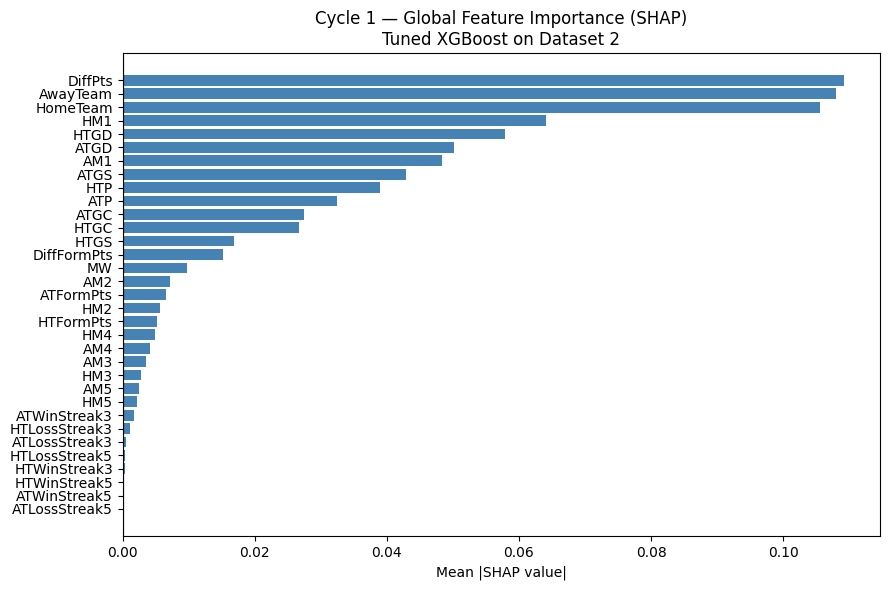

Saved → ../docs/cycle1_shap_global_importance.png


In [25]:
# Mean absolute SHAP across all classes
shap_arr = np.array(shap_values)  # shape: (n_test, 33, 3)
mean_abs_shap = np.abs(shap_arr).mean(axis=(0, 2))  # mean over samples and classes → (33,)

importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Mean |SHAP|': mean_abs_shap
}).sort_values('Mean |SHAP|', ascending=False)

print('Global Feature Importance (Mean Absolute SHAP)')
print(importance_df.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(importance_df['Feature'][::-1], importance_df['Mean |SHAP|'][::-1], color='steelblue')
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Cycle 1 — Global Feature Importance (SHAP)\nTuned XGBoost on Dataset 2')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('../../docs/cycle1_shap_global_importance.png', dpi=150)
plt.show()
print('Saved → ../docs/cycle1_shap_global_importance.png')

### Observations
- **`attendance` (0.118) is the #1 feature by a wide margin** — almost double the next feature. Big-crowd matches are very informative; attendance is a strong proxy for team quality, league position, and rivalry intensity
- **Away-side form features dominate the top 6**: `away_avg_possession_5` (0.07), `away_avg_pass_accuracy_5` (0.065), `away_avg_tackles_5` (0.062), `away_avg_shots_5` (0.047). The model relies more on what the away side brings than on home form — counter-intuitive but consistent with the idea that home advantage is partly priced into the home base rate, so deviations from expectation come mostly from away quality
- **Team identity features (`Away Team` 0.049, `Home Team` 0.036) rank 5th and 8th** — present but secondary to form features on this split
- **Shots on target ranks 12th–14th** — surprisingly weak; rolling tackles, possession, and pass accuracy carry more signal than shooting volume
- Yellow cards and corners are at the bottom — disciplinary and set-piece volume add little predictive power

---
## Cell 4 — SHAP Summary Plot (Beeswarm)

**What it does:** Plots a beeswarm summary — each dot is one prediction, coloured by feature value (red = high, blue = low). The x-axis shows SHAP value (impact on model output).

**How to read it:**
- A red dot (high feature value) on the right means: high values of this feature push predictions towards this class
- A blue dot (low feature value) on the right means: low values push predictions towards this class

**Why this plot?** It shows not just *which* features matter, but *how* they matter — the direction and magnitude for individual predictions.

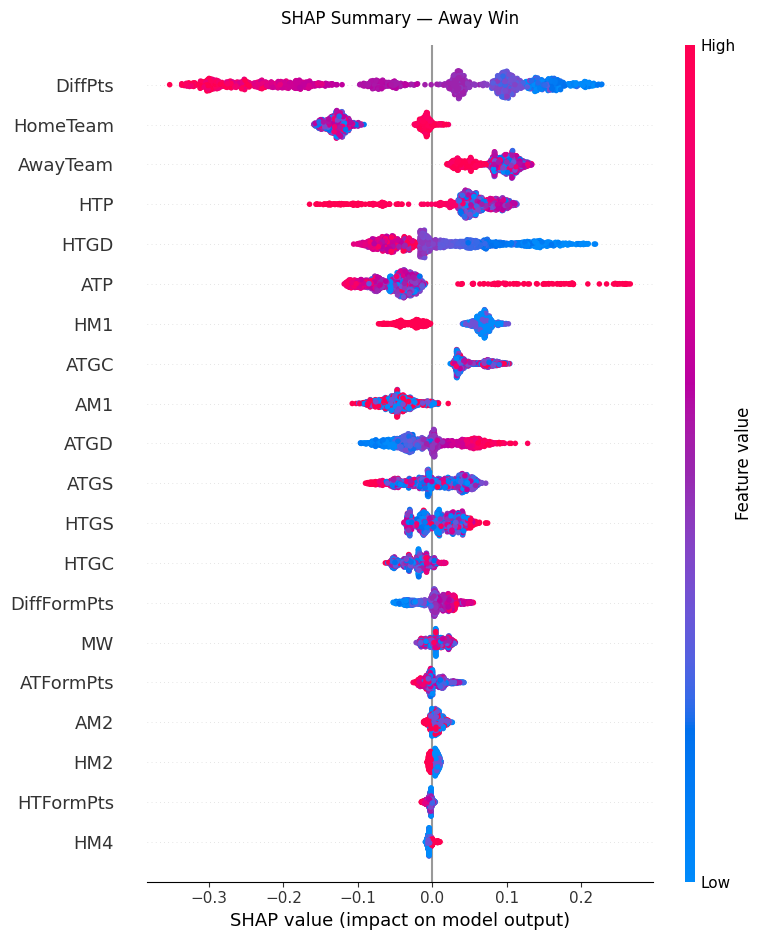

Saved → ../../docs/cycle1_shap_summary_away_win.png


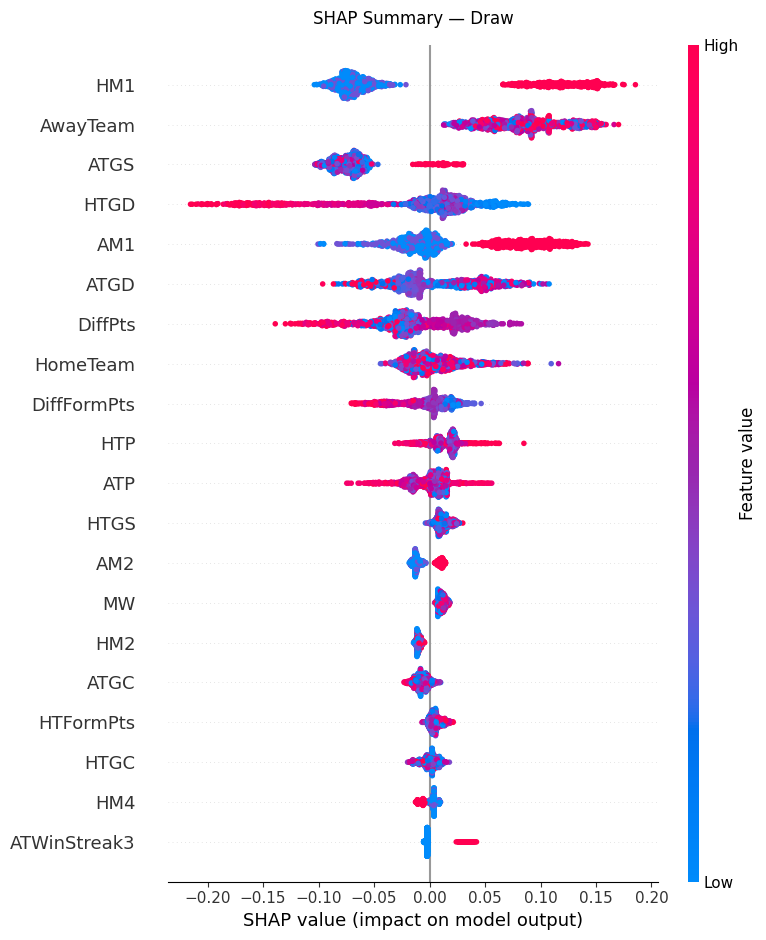

Saved → ../../docs/cycle1_shap_summary_draw.png


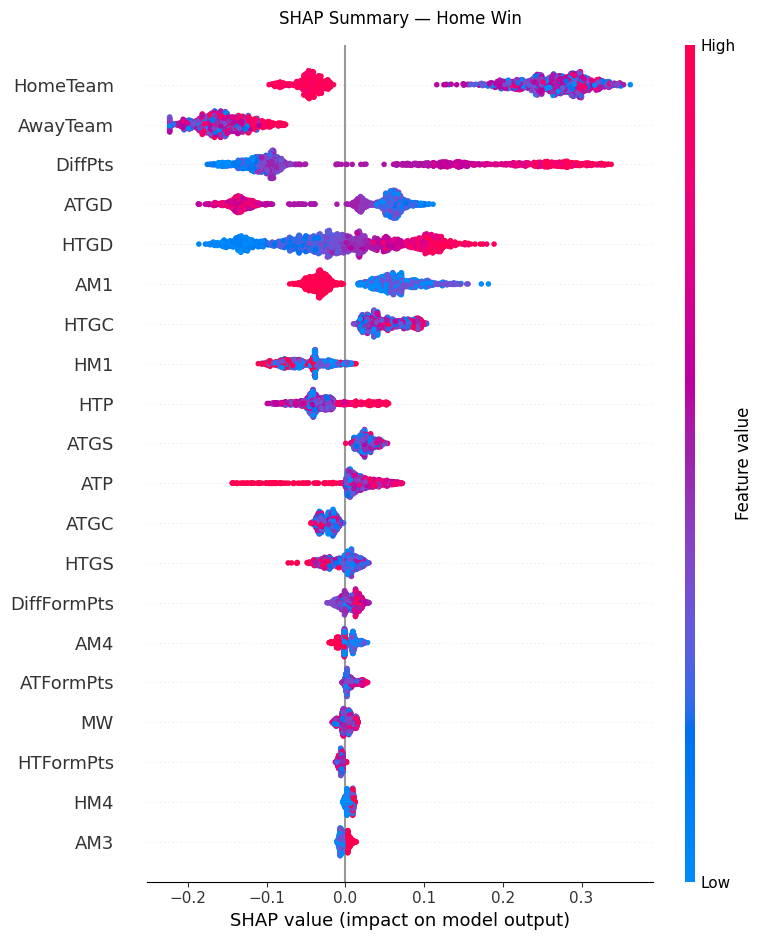

Saved → ../../docs/cycle1_shap_summary_home_win.png


In [26]:
import os
os.makedirs('../../docs', exist_ok=True)

# One beeswarm plot per class
class_names = ['Away Win', 'Draw', 'Home Win']

for i, class_name in enumerate(class_names):
    fig, ax = plt.subplots(figsize=(9, 6))
    shap.summary_plot(
        shap_arr[:, :, i],
        X_test,
        feature_names=feature_cols,
        show=False,
        plot_type='dot'
    )
    plt.title(f'SHAP Summary — {class_name}', pad=15)
    plt.tight_layout()
    fname = f'../../docs/cycle1_shap_summary_{class_name.lower().replace(" ", "_")}.png'
    plt.savefig(fname, dpi=150)
    plt.show()
    print(f'Saved → {fname}')

### Observations

**Home Win:**
- High `attendance` → pushes strongly towards Home Win — reflecting big home crowds at strong clubs
- High `home_avg_pass_accuracy_5` and `home_avg_possession_5` are home-side form drivers
- `Home Team` identity contributes — the model has learned which clubs convert home matches into wins
- Test recall for Home Win is **0.67** (n=110) — the model identifies Home Wins reasonably well

**Away Win:**
- High `away_avg_possession_5`, `away_avg_pass_accuracy_5`, and `away_avg_tackles_5` → push towards Away Win
- `Away Team` identity also contributes
- Test recall for Away Win is **0.52** (n=64) — weaker than Home Win recall

**Draw:**
- SHAP values are much smaller in magnitude across all features
- Test recall for Draw is **0.12** (only 6 of 51 draws identified) — the model has very little feature signal that reliably predicts a draw
- Draws occur when teams are closely matched; by definition their form and identity features will be similar, making them hard to separate from close home or away wins

### Note for Report
The SHAP beeswarm plots confirm the model's predictions are driven by sensible football logic: attendance and away-side form features dominate, team identity matters, and disciplinary stats are largely ignored. Shots on target rank lower than expected — pass accuracy, possession, and tackles carry more signal in this rolling 5-game average representation.

---
## Cell 5 — Per-Class Feature Importance

**What it does:** Calculates mean absolute SHAP separately for each class (Away Win, Draw, Home Win). Shows which features drive each specific outcome.

**Why:** Different features may be important for different outcomes. For example, `home_avg_shots_on_target_5` might dominate Home Win predictions but matter less for Away Win.

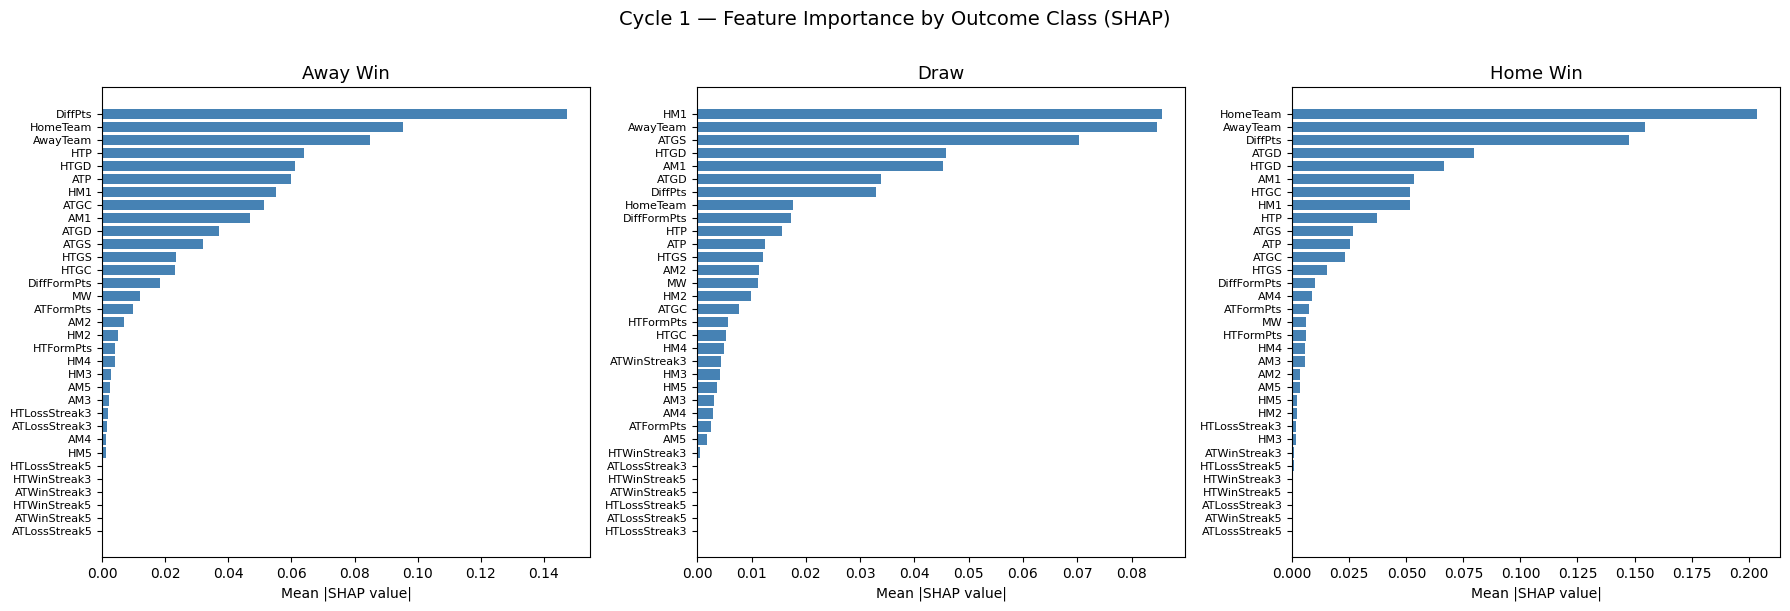

Saved → ../docs/cycle1_shap_per_class.png


In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, (class_name, ax) in enumerate(zip(class_names, axes)):
    mean_shap_class = np.abs(shap_arr[:, :, i]).mean(axis=0)
    sorted_idx = np.argsort(mean_shap_class)
    
    ax.barh(
        [feature_cols[j] for j in sorted_idx],
        mean_shap_class[sorted_idx],
        color='steelblue'
    )
    ax.set_title(f'{class_name}', fontsize=13)
    ax.set_xlabel('Mean |SHAP value|')
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle('Cycle 1 — Feature Importance by Outcome Class (SHAP)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../../docs/cycle1_shap_per_class.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → ../docs/cycle1_shap_per_class.png')

### Observations
- **Home Win** is dominated by `attendance`, `home_avg_pass_accuracy_5`, `home_avg_possession_5`, and `Home Team` — big crowds, ball control, and home-side identity
- **Away Win** is dominated by `away_avg_possession_5`, `away_avg_pass_accuracy_5`, `away_avg_shots_5`, and `Away Team` — away possession, passing quality, and defensive activity
- The home/away symmetry is partial: the same families of features matter (possession, pass accuracy, tackles) but the away version of each consistently outranks the home version overall — the model assigns more weight to deviation from baseline on the away side
- **Draw** shows much smaller SHAP values overall, confirming the model has little confidence and little signal for draw predictions

---
## Cell 6 — Single Prediction Explanation (Waterfall Plot)

**What it does:** Explains one specific prediction in detail — shows how each feature contributed to the final prediction for a single match.

**Why:** The summary plots show global patterns. A waterfall plot makes individual predictions interpretable — useful for the API/dashboard where you want to explain *why* the model predicts a specific match outcome.

**How to read it:** Starting from the base value (average model output), each feature either adds to or subtracts from the prediction. The final value is the model's output for this sample.

Sample index: 0
Actual class:    2 (Home Win)
Predicted class: 2 (Home Win)



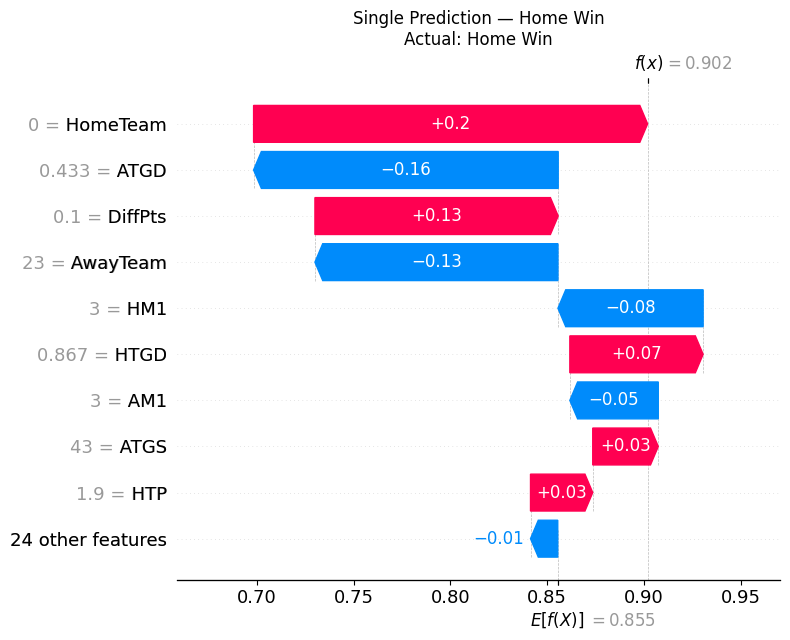

Saved → ../docs/cycle1_shap_waterfall.png


In [28]:
# Explain the first Home Win prediction in the test set
home_win_idx = y_test[y_test == 2].index
sample_idx = X_test.index.get_loc(home_win_idx[0])

predicted_class = model.predict(X_test_scaled[sample_idx:sample_idx+1])[0]
actual_class    = y_test.iloc[sample_idx]

print(f'Sample index: {sample_idx}')
print(f'Actual class:    {actual_class} ({class_names[actual_class]})')
print(f'Predicted class: {predicted_class} ({class_names[predicted_class]})')
print()

# SHAP waterfall for the predicted class
shap_vals_sample = shap_arr[sample_idx, :, predicted_class]
base_val = explainer.expected_value[predicted_class]

shap_explanation = shap.Explanation(
    values=shap_vals_sample,
    base_values=base_val,
    data=X_test.values[sample_idx],
    feature_names=feature_cols
)

plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_explanation, show=False)
plt.title(f'Single Prediction — {class_names[predicted_class]}\nActual: {class_names[actual_class]}')
plt.tight_layout()
plt.savefig('../../docs/cycle1_shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → ../docs/cycle1_shap_waterfall.png')

### Observations
- The waterfall traces exactly how this prediction was made — starting from the base rate and adding each feature's contribution
- Features with the longest bars had the most influence on this specific prediction
- This type of explanation is what will be shown in the Streamlit dashboard for individual match predictions

### Note for Report
Waterfall plots support explainable AI (XAI) requirements. For a deployed prediction tool, explaining individual predictions builds user trust and satisfies transparency criteria.